# Importo las librerias

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

# Llamo a los datos

In [2]:
Ruta_dia3 = 'Mediciones_dia3'
Archivos_dia3 = os.listdir(Ruta_dia3)
Mediciones = []
for archivo in Archivos_dia3:
    if archivo != 'Resultados_dia3.py':
        Mediciones.append(archivo)

# Lista de concentracions


In [3]:
Concentraciones = {
    'Control': ['Control', 'vacia'],
    'Fluoresceina': [0.5, 1], # hay dos concentraciones
    'Fluo-rodamina': ['11', 0.6e-5, .75e-4, .825e-5, 1.5e-6, 1.75e-5, 1.825e-5, 3.5e-5, 3.75e-6, 4.85e-5, 4.875e-6, 0.62e-4],
    'Rodamina': [0.5e-5, 1.2e-5]
}

## Datos lampara

In [4]:
# Emision de lampara
Emision_lampara = {}
Emision_lampara_datos = pd.read_pickle('Mediciones_dia3/Control/Emision.pickle')
Emision_lampara['Intensidad'] = np.array(Emision_lampara_datos['Intensidad'].iloc[0])
Emision_lampara['err_Intensidad'] = np.array(Emision_lampara_datos['err_Intensidad'].iloc[0])
Emision_lampara['Longitud_onda'] = np.array(Emision_lampara_datos['Longitud_onda'].iloc[0])
Emision_lampara['err_Longitud_onda'] = np.array(Emision_lampara_datos['err_Longitud_onda'].iloc[0])

# Emision de lampara
Absorcion_lampara = {}
Absorcion_lampara_datos = pd.read_pickle('Mediciones_dia3/Control/Absorcion.pickle')
Absorcion_lampara['Intensidad'] = np.array(Absorcion_lampara_datos['Intensidad'].iloc[0])
Absorcion_lampara['err_Intensidad'] = np.array(Absorcion_lampara_datos['err_Intensidad'].iloc[0])
Absorcion_lampara['Longitud_onda'] = np.array(Absorcion_lampara_datos['Longitud_onda'].iloc[0])
Absorcion_lampara['err_Longitud_onda'] = np.array(Absorcion_lampara_datos['err_Longitud_onda'].iloc[0])



## Datos emision

In [6]:
Emision_datos = {}

# Busco todas las concentraciones
for concentracion in Mediciones:
    Dir_concentracion = Ruta_dia3 + f'/{concentracion}' + '/Emision.pickle'
    
    print(Dir_concentracion)
    df_Emision = pd.read_pickle(Dir_concentracion)
    
    # Valores de intensidad
    try:
        Intensidad = np.array(df_Emision['Intensidad'].iloc[0])
        err_Intensidad = np.array(df_Emision['err_Intensidad'].iloc[0])


        # Valores de Longitud de onda
        Longitud = np.array(df_Emision['Longitud_onda'].iloc[0])
        err_Longitud = np.array(df_Emision['err_Longitud_onda'].iloc[0])
        
        #--> Agrego al diccionario los datos
        Emision_datos[f'Intensidad_{concentracion}'] = Intensidad
        Emision_datos[f'err_Intensidad_{concentracion}'] = err_Intensidad
        Emision_datos[f'Longitud_{concentracion}'] = Longitud
        Emision_datos[f'err_Longitud_{concentracion}'] = err_Longitud
    except Exception as e:
        print(f'Error {e}, con {Dir_concentracion}')
    
Emisiones = pd.DataFrame(Emision_datos)

Mediciones_dia3/Control/Emision.pickle
Mediciones_dia3/Fluoresceina_0.5mM/Emision.pickle
Mediciones_dia3/Fluoresceina_0.5mMdecantado/Emision.pickle
Mediciones_dia3/Fluoresceina_1mM/Emision.pickle
Mediciones_dia3/FluRo_11/Emision.pickle
Mediciones_dia3/Rodamina0.5e-5/Emision.pickle
Mediciones_dia3/Rodamina1.2e-5M/Emision.pickle
Error 'Intensidad', con Mediciones_dia3/Rodamina1.2e-5M/Emision.pickle
Mediciones_dia3/Ro_0.6e-5_flu/Emision.pickle
Mediciones_dia3/Ro_0.75e-4_flu/Emision.pickle
Mediciones_dia3/Ro_0.825e-5_flu/Emision.pickle
Mediciones_dia3/Ro_062e-4_flu/Emision.pickle
Mediciones_dia3/Ro_1.5e-6M_flu/Emision.pickle
Mediciones_dia3/Ro_1.75e-5_flu/Emision.pickle
Mediciones_dia3/Ro_1.825e-5_flu/Emision.pickle
Mediciones_dia3/Ro_3.5e-5_Flu/Emision.pickle
Mediciones_dia3/Ro_3.75e-6_flu/Emision.pickle
Mediciones_dia3/Ro_4.85e-5_Flu/Emision.pickle
Mediciones_dia3/Ro_4.875e-6_Flue/Emision.pickle
Error 'Intensidad', con Mediciones_dia3/Ro_4.875e-6_Flue/Emision.pickle
Mediciones_dia3/Vacia

## Datos abosorcion

In [7]:
Absorcion_datos = {}

# Busco todas las concentraciones
for concentracion in Mediciones:
    Dir_concentracion = Ruta_dia3 + f'/{concentracion}' + '/Absorcion.pickle'
    
    df_Absorcion = pd.read_pickle(Dir_concentracion)
    
    try:
        # Valores de intensidad
        Intensidad = np.array(df_Absorcion['Intensidad'].iloc[0])
        err_Intensidad = np.array(df_Absorcion['err_Intensidad'].iloc[0])


        # Valores de Longitud de onda
        Longitud = np.array(df_Absorcion['Longitud_onda'].iloc[0])
        err_Longitud = np.array(df_Absorcion['err_Longitud_onda'].iloc[0])
        
        #--> Agrego al diccionario los datos
        Absorcion_datos[f'Intensidad_{concentracion}'] = Intensidad
        Absorcion_datos[f'err_Intensidad_{concentracion}'] = err_Intensidad
        Absorcion_datos[f'Longitud_{concentracion}'] = Longitud
        Absorcion_datos[f'err_Longitud_{concentracion}'] = err_Longitud
    except Exception as e:
        print(f'Error {e}, con {Dir_concentracion}')
    
Absorciones = pd.DataFrame(Absorcion_datos)

# Figuras

In [8]:
a = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8])
a[a < 5]

array([0, 1, 2, 3, 4])

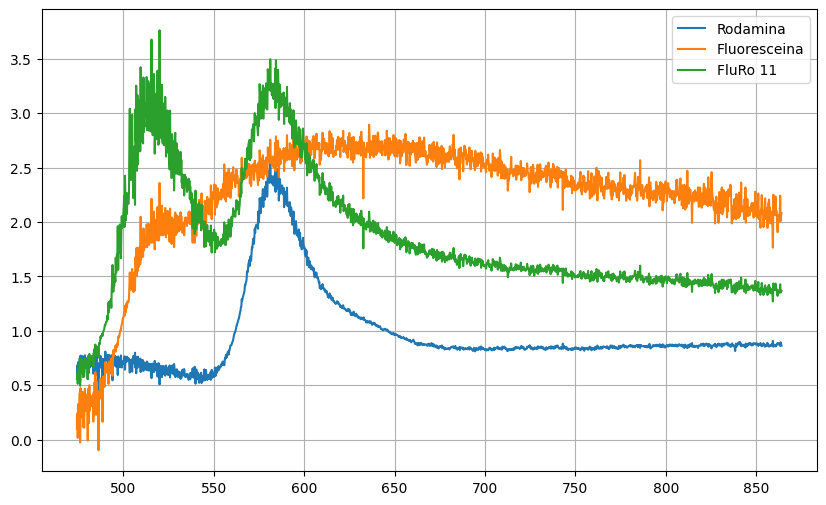

In [19]:
plt.figure(figsize = (10, 6))

a, b = 1_300, 3_000
# Rodamina absorcion
plt.plot(Emision_datos['Longitud_Rodamina0.5e-5'][a:b], Emision_datos['Intensidad_Rodamina0.5e-5'][a:b] / Emision_lampara['Intensidad'][a:b],
         label = 'Rodamina')

# Fluo emision
plt.plot(Emision_datos['Longitud_Fluoresceina_1mM'][a:b], Emision_datos['Intensidad_Fluoresceina_1mM'][a:b] / Emision_lampara['Intensidad'][a:b],
         label = 'Fluoresceina')

# Ambas
plt.plot(Emision_datos['Longitud_FluRo_11'][a:b], Emision_datos['Intensidad_FluRo_11'][a:b] / Emision_lampara['Intensidad'][a:b],
         label = 'FluRo 11')


plt.grid(), plt.legend(loc = 'upper right')
plt.show()

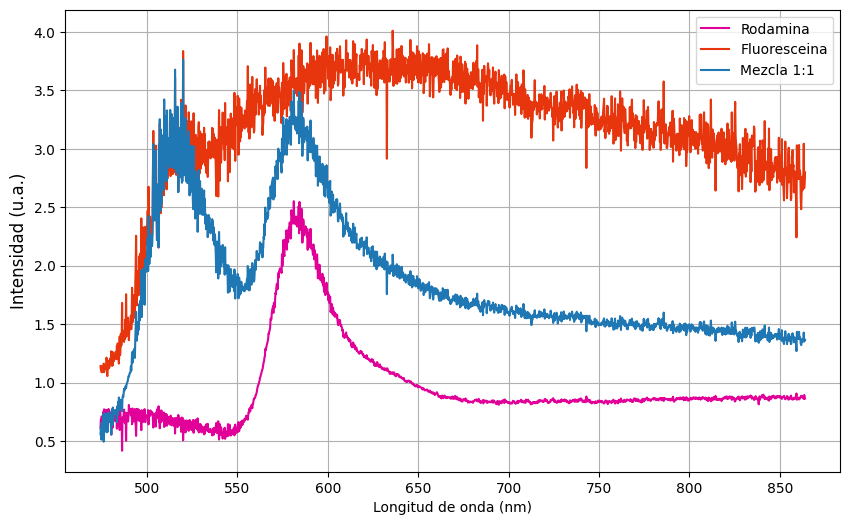

In [ ]:
plt.figure(figsize = (10, 6))

a, b = 1_300, 3_000
# Rodamina emision
plt.plot(Emision_datos['Longitud_Rodamina0.5e-5'][a:b],
        Emision_datos['Intensidad_Rodamina0.5e-5'][a:b] / Emision_datos['Intensidad_Control'][a:b],
         label = 'Rodamina',color = '#E10098')

# Fluo emision
plt.plot(Emision_datos['Longitud_Fluoresceina_1mM'][a:b],
        Emision_datos['Intensidad_Fluoresceina_0.5mM'][a:b] / Emision_datos['Intensidad_Control'][a:b],
        label = 'Fluoresceina',color = "#E7360EFF")

# Ambas
plt.plot(Emision_datos['Longitud_FluRo_11'][a:b],
        Emision_datos['Intensidad_FluRo_11'][a:b] / Emision_datos['Intensidad_Control'][a:b],
         label = 'Mezcla 1:1')

plt.xlabel('Longitud de onda (nm)'), plt.ylabel('Intensidad (u.a.)',fontsize = 12)
plt.grid(), plt.legend(loc = 'upper right')
plt.show()

In [565]:
# Defino las concentraciones en orden y calculo la fluorescencia del donor sin acepptor
concentraciones = np.array(['3.75e-6','0.5e-5','0.6e-5','0.825e-5','1.75e-5','1.825e-5','4.85e-5','0.75e-4'])
# '1.5e-6','0.5e-5'


In [566]:
# Calculo para cada concentracion de acceptor la florescencia del donor
F_das = []
for concentracion in concentraciones:
    if concentracion == '0.62e-4':
        F_das.append(Emision_datos[f'Intensidad_Ro_062e-4_flu']/Emision_datos['Intensidad_Control'])
    elif concentracion == '1.5e-6':
        F_das.append(Emision_datos[f'Intensidad_Ro_{concentracion}M_flu']/Emision_datos['Intensidad_Control'])
    elif concentracion == '3.5e-5' or concentracion == '4.85e-5':
        F_das.append(Emision_datos[f'Intensidad_Ro_{concentracion}_Flu']/Emision_datos['Intensidad_Control'])
    elif concentracion == '0.5e-5':
        F_das.append(Emision_datos[f'Intensidad_Rodamina{concentracion}']/Emision_datos['Intensidad_Control'])
    else:
        F_das.append(Emision_datos[f'Intensidad_Ro_{concentracion}_flu']/Emision_datos['Intensidad_Control'])
    

F_das = np.array(F_das)


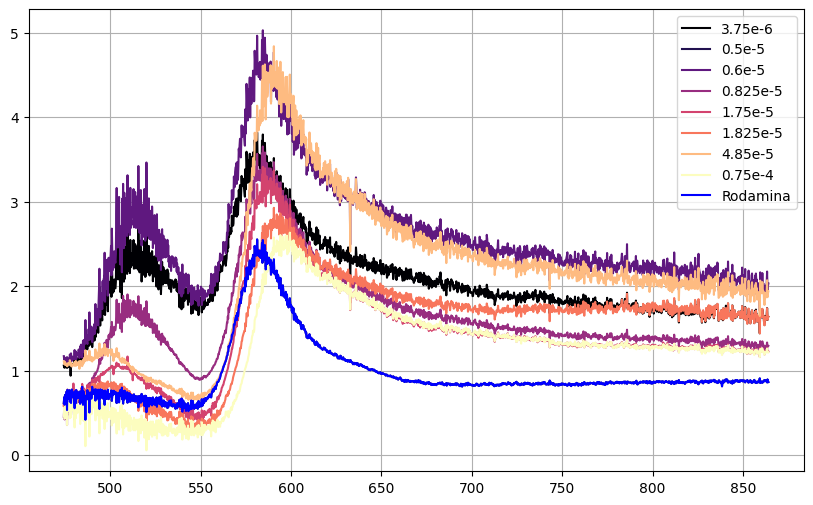

In [580]:
plt.figure(figsize = (10, 6))

a, b = 1_300, 3_000
cmap = plt.cm.magma  

# Concentraciones
for i in np.arange(0,len(F_das)):
    plt.plot(Emision_datos['Longitud_FluRo_11'][a:b], F_das[i][a:b],
         label = f'{concentraciones[i]}',color = cmap(i/7))
    
# Rodamina emision
plt.plot(Emision_datos['Longitud_Rodamina0.5e-5'][a:b], Emision_datos['Intensidad_Rodamina0.5e-5'][a:b] / Emision_datos['Intensidad_Control'][a:b],
         label = 'Rodamina',c ='blue')


plt.grid(), plt.legend(loc = 'upper right')
plt.show()

# Analisis de eficiciencia

$E = 1 - \frac{F_{DA}}{F_D}$ 

$F_{DA}$: donor fluorescence intensities with acceptor

$F_A$: donor fluorescence intensities without an acceptor

In [518]:
# Con esto elijo un dato fijo que corresponde a algun lambda, trato de que sea en el pico de rhodamina
posicion_lambda = 1510

In [519]:
# Defino las concentraciones en orden y calculo la fluorescencia del donor sin acepptor
concentraciones = np.array(['3.75e-6','0.6e-5','0.825e-5','1.75e-5','1.825e-5','3.5e-5','4.85e-5','0.62e-4','0.75e-4'])
# '1.5e-6','0.5e-5'
F_a = Emision_datos['Intensidad_Fluoresceina_0.5mM'][posicion_lambda]/Emision_datos['Intensidad_Control'][posicion_lambda]


In [520]:
# Calculo para cada concentracion de acceptor la florescencia del donor
F_das = []
for concentracion in concentraciones:
    if concentracion == '0.62e-4':
        F_das.append(Emision_datos[f'Intensidad_Ro_062e-4_flu']/Emision_datos['Intensidad_Control'])
    elif concentracion == '1.5e-6':
        F_das.append(Emision_datos[f'Intensidad_Ro_{concentracion}M_flu']/Emision_datos['Intensidad_Control'])
    elif concentracion == '3.5e-5' or concentracion == '4.85e-5':
        F_das.append(Emision_datos[f'Intensidad_Ro_{concentracion}_Flu']/Emision_datos['Intensidad_Control'])
    elif concentracion == '0.5e-5':
        F_das.append(Emision_datos[f'Intensidad_Rodamina{concentracion}']/Emision_datos['Intensidad_Control'])
    else:
        F_das.append(Emision_datos[f'Intensidad_Ro_{concentracion}_flu']/Emision_datos['Intensidad_Control'])
    

F_das = np.array(F_das)

# La florescencia que dije arriba para cada concentracion en la posicion elegida
F_das[:,posicion_lambda]

array([2.30436923, 2.79337817, 1.59621291, 0.82824036, 0.5598611 ,
       0.22591692, 0.90006859, 0.21209849, 0.30148567])

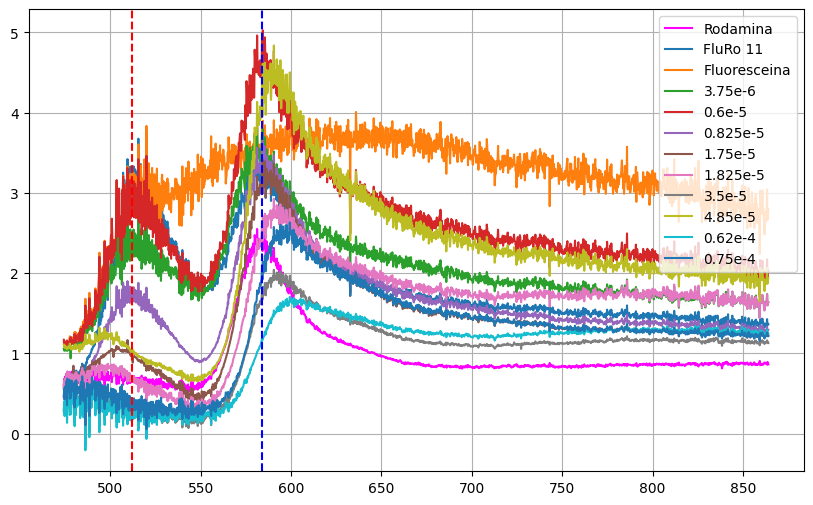

In [521]:
plt.figure(figsize = (10, 6))

a, b = 1_300, 3_000
# Rodamina emision
plt.plot(Emision_datos['Longitud_Rodamina0.5e-5'][a:b], Emision_datos['Intensidad_Rodamina0.5e-5'][a:b] / Emision_datos['Intensidad_Control'][a:b],
         label = 'Rodamina',c = 'magenta')

# Ambas
plt.plot(Emision_datos['Longitud_FluRo_11'][a:b], Emision_datos['Intensidad_FluRo_11'][a:b] / Emision_datos['Intensidad_Control'][a:b],
         label = 'FluRo 11')

# Floresceina emision
plt.plot(Emision_datos['Longitud_Fluoresceina_0.5mM'][a:b], Emision_datos['Intensidad_Fluoresceina_0.5mM'][a:b] / Emision_datos['Intensidad_Control'][a:b],
         label = 'Fluoresceina')

# Concentraciones
for i in np.arange(0,len(F_das)):
    plt.plot(Emision_datos['Longitud_FluRo_11'][a:b], F_das[i][a:b],
         label = f'{concentraciones[i]}')


plt.axvline(Emision_datos['Longitud_Control'][1470],c = 'red',linestyle = '--')
plt.axvline(Emision_datos['Longitud_Control'][1790],c = 'blue',linestyle = '--')
plt.grid(), plt.legend(loc = 'upper right')
plt.show()

In [522]:
# Calculo cada eficiencia por concentracion el la posicion elegida
E = []
for i in F_das[:,posicion_lambda]:
    E.append(1-(i/F_a))

# Cambio las concentraciones a numeros
concentraciones = concentraciones.astype('float')
concentraciones
E

[np.float64(0.2515926714565673),
 np.float64(0.09277356064110442),
 np.float64(0.4815859258290943),
 np.float64(0.7310061482692309),
 np.float64(0.8181697001216027),
 np.float64(0.9266272610381375),
 np.float64(0.7076779533998333),
 np.float64(0.9311151795377587),
 np.float64(0.9020842311461706)]

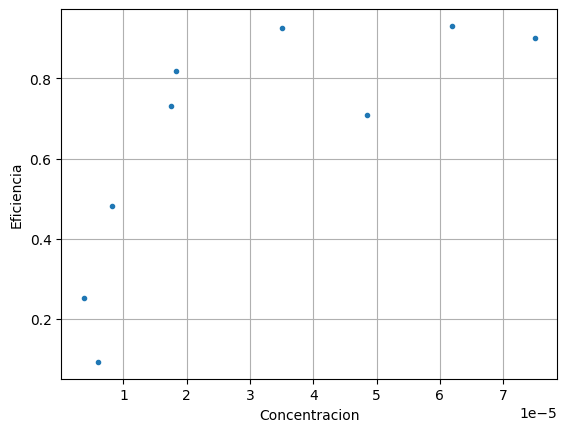

In [523]:
plt.figure()
plt.plot(concentraciones,E,'.')
plt.xlabel('Concentracion')
plt.ylabel('Eficiencia')
plt.grid()

# Prueba

In [524]:
posicion_lambda = 1780

In [525]:
# Defino las concentraciones en orden y calculo la fluorescencia del donor sin acepptor
concentraciones = np.array(['3.75e-6','0.825e-5','1.75e-5','0.62e-4'])
# '1.5e-6','0.5e-5','0.6e-5','1.825e-5','3.5e-5','4.85e-5','0.75e-4'
F_a = Emision_datos['Intensidad_Ro_1.5e-6M_flu'][posicion_lambda]/Emision_datos['Intensidad_Control'][posicion_lambda]


In [526]:
# Calculo para cada concentracion de acceptor la florescencia del donor
F_das = []
for concentracion in concentraciones:
    if concentracion == '0.62e-4':
        F_das.append(Emision_datos[f'Intensidad_Ro_062e-4_flu']/Emision_datos['Intensidad_Control'])
    elif concentracion == '1.5e-6':
        F_das.append(Emision_datos[f'Intensidad_Ro_{concentracion}M_flu']/Emision_datos['Intensidad_Control'])
    elif concentracion == '3.5e-5' or concentracion == '4.85e-5':
        F_das.append(Emision_datos[f'Intensidad_Ro_{concentracion}_Flu']/Emision_datos['Intensidad_Control'])
    elif concentracion == '0.5e-5':
        F_das.append(Emision_datos[f'Intensidad_Rodamina{concentracion}']/Emision_datos['Intensidad_Control'])
    else:
        F_das.append(Emision_datos[f'Intensidad_Ro_{concentracion}_flu']/Emision_datos['Intensidad_Control'])
    

F_das = np.array(F_das)

# La florescencia que dije arriba para cada concentracion en la posicion elegida
F_das[:,posicion_lambda]

array([3.55859853, 3.33867239, 3.02312197, 1.02711349])

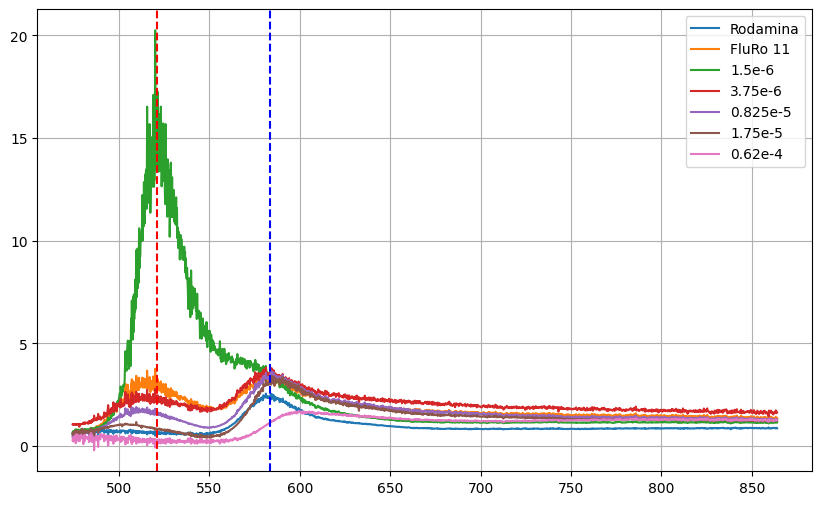

In [527]:
plt.figure(figsize = (10, 6))

a, b = 1_300, 3_000
# Rodamina emision
plt.plot(Emision_datos['Longitud_Rodamina0.5e-5'][a:b], Emision_datos['Intensidad_Rodamina0.5e-5'][a:b] / Emision_datos['Intensidad_Control'][a:b],
         label = 'Rodamina')

# Ambas
plt.plot(Emision_datos['Longitud_FluRo_11'][a:b], Emision_datos['Intensidad_FluRo_11'][a:b] / Emision_datos['Intensidad_Control'][a:b],
         label = 'FluRo 11')

# Floresceina emision
#plt.plot(Emision_datos['Longitud_Fluoresceina_0.5mM'][a:b], Emision_datos['Intensidad_Fluoresceina_0.5mM'][a:b] / Emision_datos['Intensidad_Control'][a:b],
#         label = 'Fluoresceina')

plt.plot(Emision_datos['Longitud_Ro_1.5e-6M_flu'][a:b], Emision_datos['Intensidad_Ro_1.5e-6M_flu'][a:b] / Emision_datos['Intensidad_Control'][a:b],
         label = '1.5e-6')

# Concentraciones
for i in np.arange(0,len(F_das)):
    plt.plot(Emision_datos['Longitud_FluRo_11'][a:b], F_das[i][a:b],
         label = f'{concentraciones[i]}')


plt.axvline(Emision_datos['Longitud_Control'][1510],c = 'red',linestyle = '--')
plt.axvline(Emision_datos['Longitud_Control'][1790],c = 'blue',linestyle = '--')
plt.grid(), plt.legend(loc = 'upper right')
plt.show()

In [528]:
# Calculo cada eficiencia por concentracion el la posicion elegida
E = []
for i in F_das[:,posicion_lambda]:
    E.append(1-(i/F_a))

# Cambio las concentraciones a numeros
concentraciones = concentraciones.astype('float')
concentraciones
E

[np.float64(0.018772130970599155),
 np.float64(0.07941332282002),
 np.float64(0.1664214132616607),
 np.float64(0.7167895255801009)]

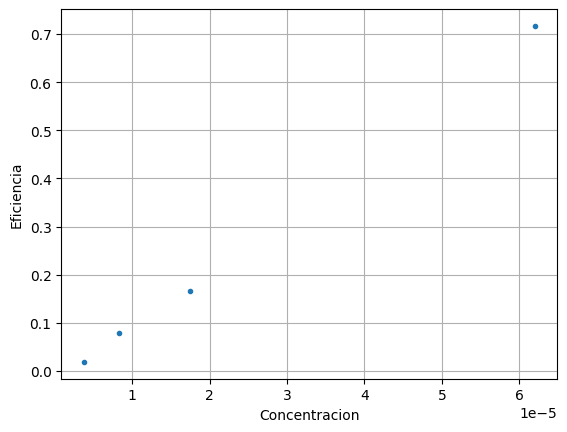

In [529]:
plt.figure()
plt.plot(concentraciones,E,'.')
plt.xlabel('Concentracion')
plt.ylabel('Eficiencia')
plt.grid()

# Espectro de rhodamina, fluoresceina y mezcla
Esta parte es si usamos el de menor concnetracion en vez del real de flouresceina

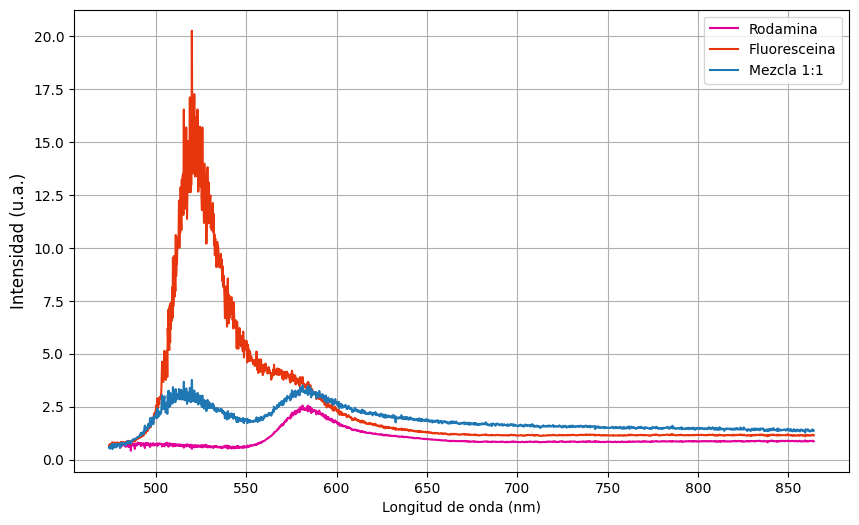

In [530]:
plt.figure(figsize = (10, 6))

a, b = 1_300, 3_000
# Rodamina emision
plt.plot(Emision_datos['Longitud_Rodamina0.5e-5'][a:b],
        Emision_datos['Intensidad_Rodamina0.5e-5'][a:b] / Emision_datos['Intensidad_Control'][a:b],
         label = 'Rodamina',color = '#E10098')

# Fluo emision
plt.plot(Emision_datos['Longitud_Ro_1.5e-6M_flu'][a:b],
        Emision_datos['Intensidad_Ro_1.5e-6M_flu'][a:b] / Emision_datos['Intensidad_Control'][a:b],
        label = 'Fluoresceina',color = "#E7360EFF")

# Ambas
plt.plot(Emision_datos['Longitud_FluRo_11'][a:b],
        Emision_datos['Intensidad_FluRo_11'][a:b] / Emision_datos['Intensidad_Control'][a:b],
         label = 'Mezcla 1:1')

plt.xlabel('Longitud de onda (nm)'), plt.ylabel('Intensidad (u.a.)',fontsize = 12)
plt.grid(), plt.legend(loc = 'upper right')
plt.show()

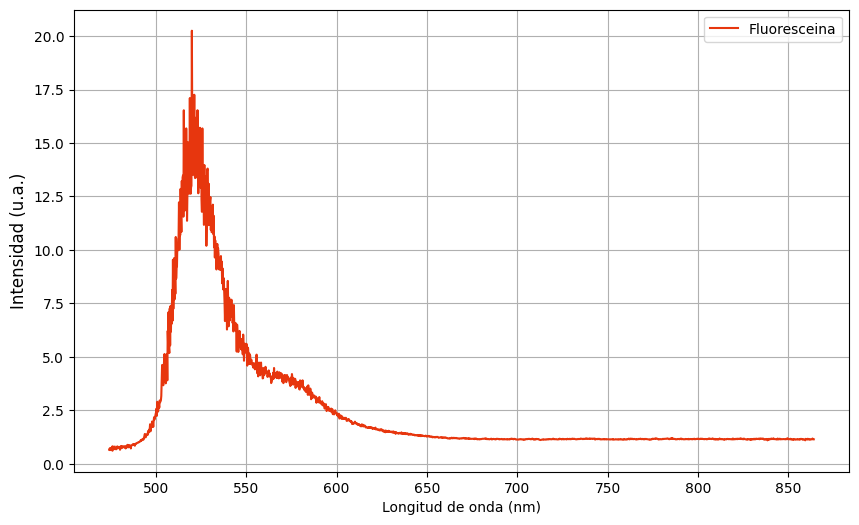

In [531]:
plt.figure(figsize = (10, 6))

a, b = 1_300, 3_000


# Fluo emision
plt.plot(Emision_datos['Longitud_Ro_1.5e-6M_flu'][a:b],
        Emision_datos['Intensidad_Ro_1.5e-6M_flu'][a:b] / Emision_datos['Intensidad_Control'][a:b],
        label = 'Fluoresceina',color = "#E7360EFF")



plt.xlabel('Longitud de onda (nm)'), plt.ylabel('Intensidad (u.a.)',fontsize = 12)
plt.grid(), plt.legend(loc = 'upper right')
plt.show()